```
<01_Crawling.ipynb>

제미나이 의존도: 50-60%

selenium 라이브러리를 사용해서 처음으로 크롤링(Crawling)을 구현한 코드입니다.
구글에 "신선한 사과"를 검색하여 신선한 사과 이미지를 크롤링 했습니다.
처음이다보니 현재 위치(pwd)를 찍어보는 등 여러가지 삽질(좋게 말하면 시행착오)을 하면서 크롤링에 성공했습니다.
```

In [6]:
import selenium
print(selenium.__version__)

4.44.0


In [51]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import time
from selenium.webdriver.chrome.options import Options

chrome_options = Options()

chrome_options.add_argument("--headless=new")

driver = webdriver.Chrome(options=chrome_options)

driver.get("https://google.com")

# driver = webdriver.Chrome()

# driver.get("https://google.com")

# time.sleep(3)



In [35]:
from selenium.webdriver.common.keys import Keys
import random
search_box = driver.find_element(By.NAME, "q")

search_box.send_keys("신선한 사과")
time.sleep(random.uniform(1.0, 3.0))
search_box.send_keys(Keys.ENTER)


In [36]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

image_tab = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.LINK_TEXT, '이미지'))
)
image_tab.click()

time.sleep(random.uniform(2.0, 4.0))


In [37]:
images = driver.find_elements(By.CLASS_NAME, "YQ4gaf")
print(len(images))

212


img_url: https://www.google.com/logos/doodles/2026/world-cup-2026-the-art-of-the-save-615-6753651837111101-shsdrk.png
img_url: 
img_url: 
img_url: 
img_url: 
img_url: 
img_url: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRtixe_CDF65-O9pzSxxrVHYGfdVpLOnYsIijiAt0ojOXeYK3rsXh4cxoeB&s
img_url: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSdCs1UCyScC8z-3PRs1YxyygYiVxbClV62vFJYw4Ff21lVLPPtxZa6iFK2&s
img_url: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTzrSbv1XqFlb3HenLpMBE3LGvQV_8916blUx8qIfWpjGj1TbKnJ7yOhshD&s
img_url: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR01VOaHhx6y-Y4epmHoLnBac_rj7KF2C9Vl-pHjMdsTl7oU2jI2wJtSk1X&s

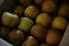
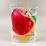
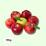
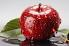
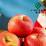

In [38]:
for idx, image in enumerate(images):
    img_url = image.get_attribute("src")
    print(f"img_url: {img_url}")

    if idx >= 9:
        break

<class 'list'>
url: https://www.google.com/logos/doodles/2026/world-cup-2026-the-art-of-the-save-615-6753651837111101-shsdrk.png
url: 
url: 
url: 
url: 
url: 
url: 
url: 
url: 
url: 
count: 99
99

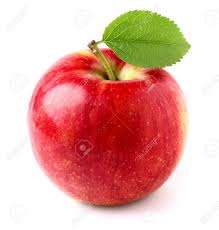
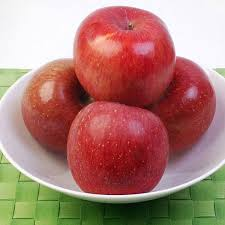
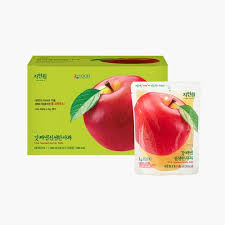
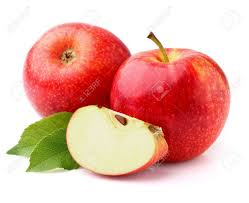
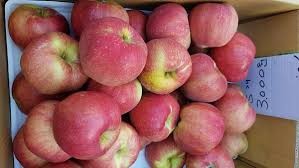
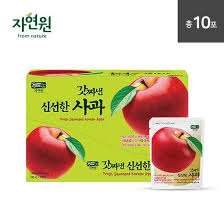
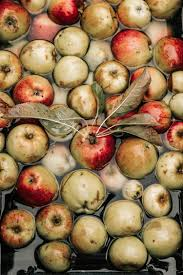
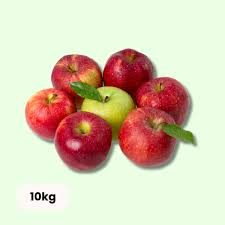
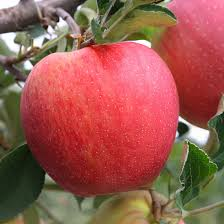

In [40]:
image_url_list = []
count = 0
print(type(images))
for idx, image in enumerate(images):
    img_size = image.size

    if img_size["width"] >= 50 and img_size["height"] >= 50:
        url = image.get_attribute("src")
        image_url_list.append(url)
        if count <= 9:
            print(f"url: {url}")
        count += 1

print(f"count: {count}")
print(len(image_url_list))

In [47]:
import urllib.request

for idx, image_url in enumerate(image_url_list):
    urllib.request.urlretrieve(image_url, f"apple_images/apple_{idx}.jpg")
    time.sleep(random.uniform(0.5, 1.5))

In [46]:
!pwd

/Users/jeongjaehun/Crawling


In [50]:
driver.quit()